## API Endpoints

### 1. `searchAddCo` – Co-regulated lncRNA Pairs

**Endpoint:**
```
https://bio-bigdata.hrbmu.edu.cn/scolnc/searchAddCo?cancer={cancer}&name={lncRNA}&geneId={geneId}&cellType={cellType}
```

**Request Parameters:**

| Parameter | Type | Description |
|-----------|------|-------------|
| `cancer` | string | Cancer type, e.g., `CRC`, `ATC(Anaplastic+Thyroid+Cancer)` |
| `name` | string | lncRNA name to query, e.g., `MEG3` |
| `geneId` | string | Ensembl gene ID (optional) |
| `cellType` | string | Filter by specific cell type (optional) |

**Key Response Fields:**

| Field | Description |
|-------|-------------|
| `geneId1` / `geneId2` | Ensembl IDs of the two lncRNAs |
| `lncRna1` / `lncRna2` | Names of the two lncRNAs |
| `cellType` | Cell type where the pair is co-regulated |
| `tumorType` | Cancer type |
| `jaccordIndex` | Jaccard index measuring co-regulation overlap |
| `intensityScore` | Co-regulation intensity score |
| `functionalType` | Functional annotation type (`GO`, `KEGG`, `IMMUNE`) |
| `functional` | Associated functions or pathways (semicolon-separated) |
| `km` | Kaplan-Meier survival indicator (0/1) |
| `kmIndex` | URL to KM survival plot |

---

### 2. `searchAddSp` – Cell Type-Specific lncRNA

**Endpoint:**
```
https://bio-bigdata.hrbmu.edu.cn/scolnc/searchAddSp?cancer={cancer}&name={lncRNA}&geneId={geneId}&cellType={cellType}
```

**Request Parameters:**

| Parameter | Type | Description |
|-----------|------|-------------|
| `cancer` | string | Cancer type, e.g., `CRC`, `ATC(Anaplastic+Thyroid+Cancer)` |
| `name` | string | lncRNA name to query, e.g., `MEG3` |
| `geneId` | string | Ensembl gene ID (optional) |
| `cellType` | string | Filter by specific cell type (optional) |

**Key Response Fields:**

| Field | Description |
|-------|-------------|
| `geneId` | Ensembl ID of the lncRNA |
| `lncRNA` | lncRNA name |
| `tumorType` | Cancer type |
| `cellType` | Cell type of expression |
| `avgLog2FC` | Average log2 fold change (expression level) |
| `pct1` / `pct2` | Percentage of cells expressing in two conditions |
| `pval` | Statistical significance p-value |
| `pvalAdj` | Adjusted p-value |
| `function` | Associated GO/KEGG functions (semicolon-separated) |
| `funcState` | Whether functional annotation exists (1 = yes) |
| `lncfunc` | Whether co-regulation exists (1 = yes) |
| `funcIndex` | URL to detailed function page |
| `lncColncIndex` | URL to co-regulation details |

##  Example 1

### Cell Composition Landscape of CRC

C:\WINDOWSl\Temp\ipykernel_23816\1561962855.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df, x='subtype', y='percentage', palette='viridis')


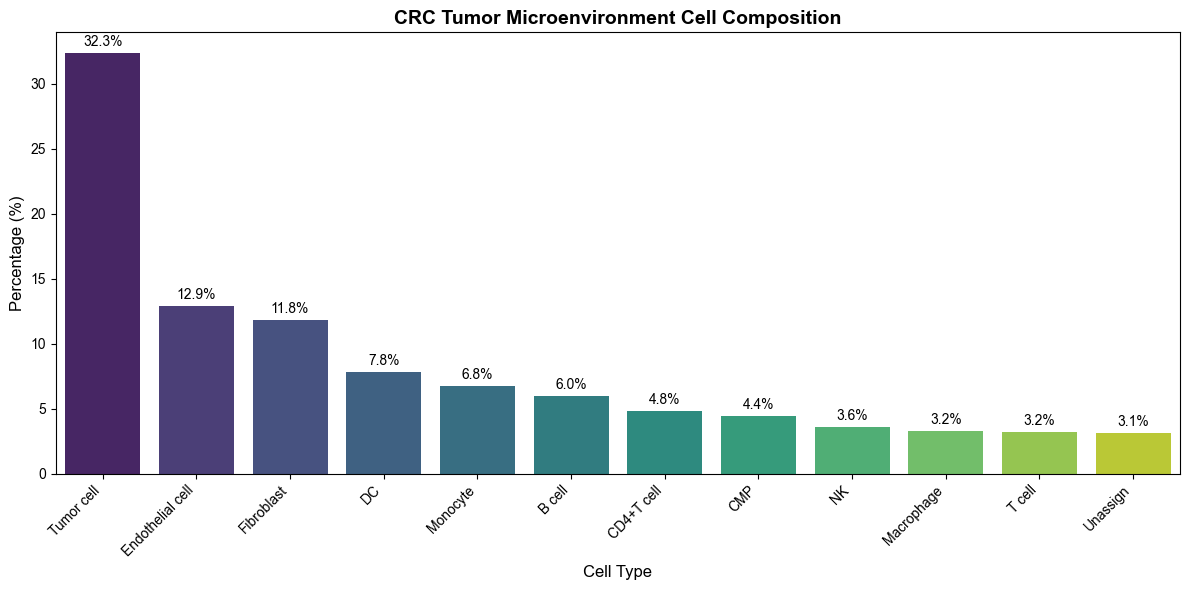

In [22]:
from curl_cffi import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set Arial font
plt.rcParams['font.family'] = 'Arial'

Tumor = 'CRC'
# Fetch data
API = f"https://bio-bigdata.hrbmu.edu.cn/scolnc/searchCancerProp?cancer={Tumor}"
response = requests.get(API, impersonate="chrome")
data = response.json()

# Prepare DataFrame
df = pd.DataFrame(data['data']['rows'])
df['percentage'] = df['percentage'].astype(float) * 100
df = df.sort_values('percentage', ascending=False)

# Plot
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=df, x='subtype', y='percentage', palette='viridis')
plt.title(f'{Tumor} Tumor Microenvironment Cell Composition', fontsize=14, fontweight='bold')
plt.xlabel('Cell Type', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')

# Add value labels
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 8), textcoords='offset points')

plt.tight_layout()
plt.show()

### Co-regulated lncRNA Interactome in CRC

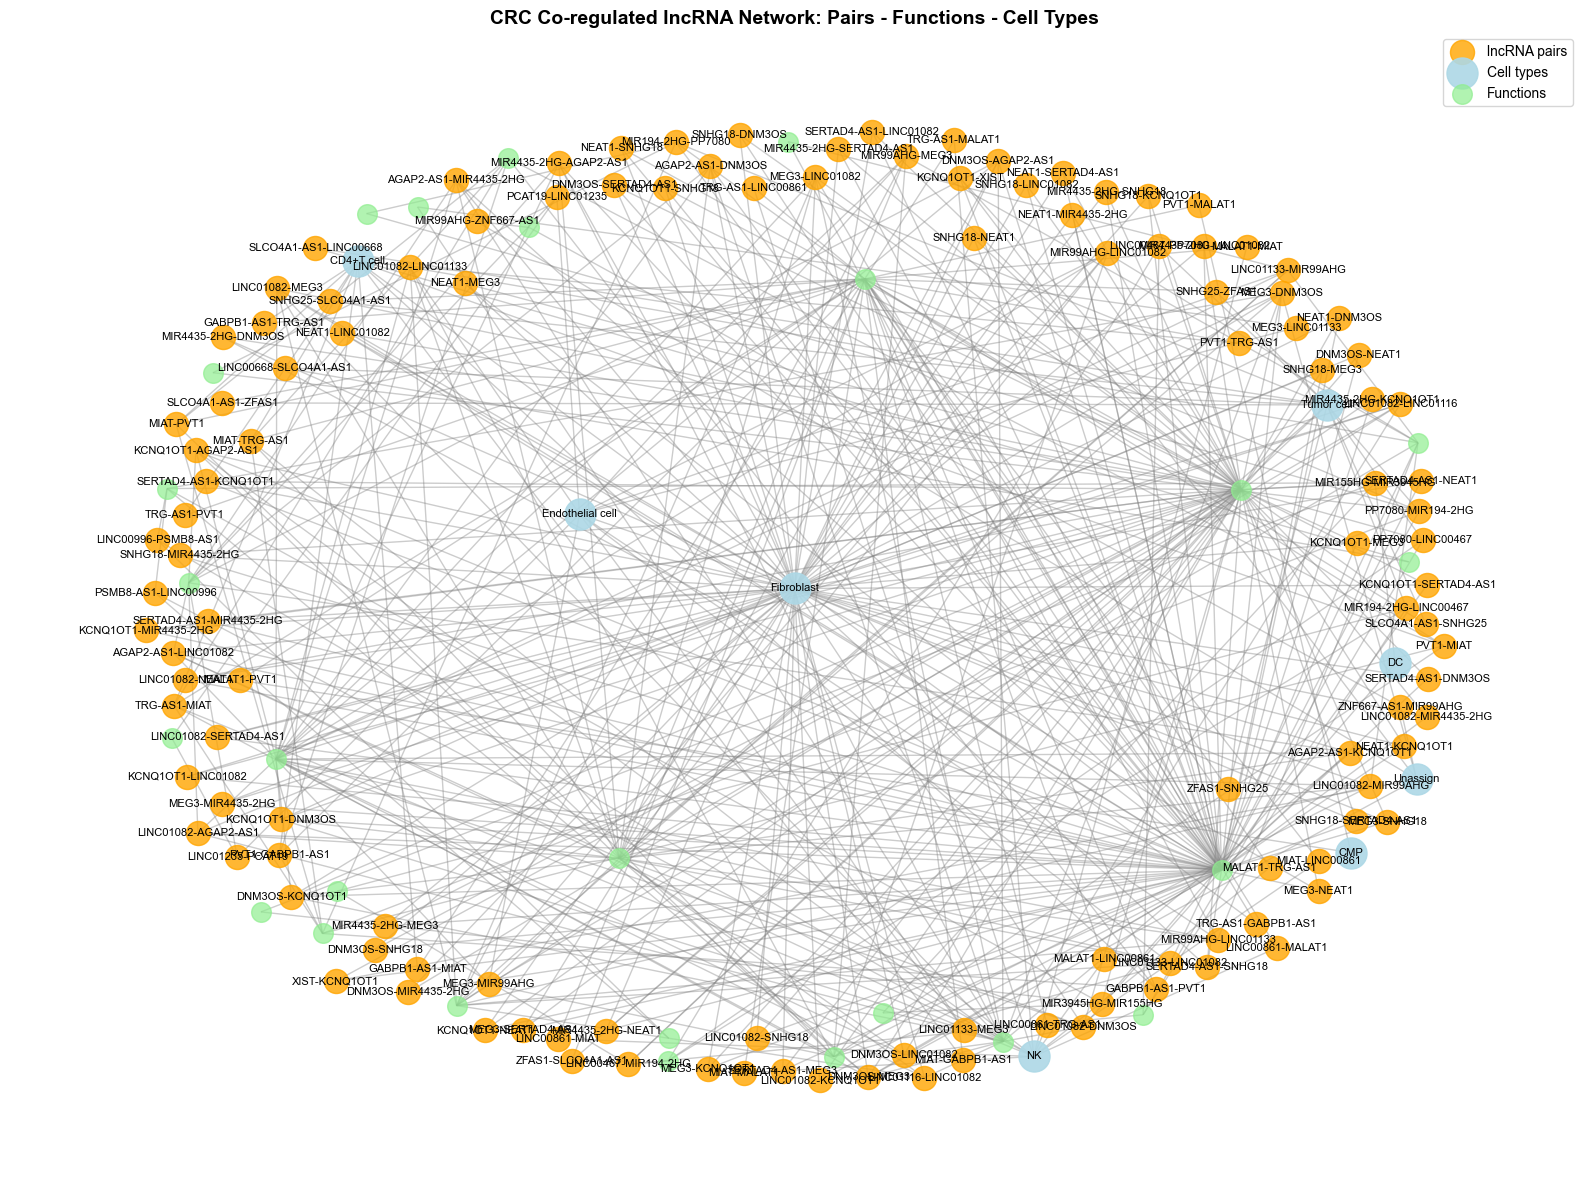

Total nodes: 158
  lncRNA pairs: 124
  Cell types: 8
  Functions: 26
Total edges: 452


In [22]:
from curl_cffi import requests
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict

# Set Arial font
plt.rcParams['font.family'] = 'Arial'

# Configuration
Tumor = 'CRC'
API = f"https://bio-bigdata.hrbmu.edu.cn/scolnc/searchAddCo?cancer={Tumor}"

# Fetch data
response = requests.get(API, impersonate="chrome")
data = response.json()
df = pd.DataFrame(data['data'])

# Build network: lncRNA pair -> functions -> cell types
G = nx.Graph()

# Add nodes and edges
for _, row in df.iterrows():
    lnc_pair = f"{row['lncRna1']}-{row['lncRna2']}"
    cell = row['cellType']
    functions = row['functional'].split(';') if pd.notna(row['functional']) else []
    
    # Add lncRNA pair node
    G.add_node(lnc_pair, type='lncRNA', size=200)
    
    # Add cell type node
    G.add_node(cell, type='cell', size=100)
    G.add_edge(lnc_pair, cell, weight=row['intensityScore'])
    
    # Add function nodes and edges (limit to first 5 for readability)
    for func in functions[:5]:  # Limit to avoid overcrowding
        func_short = func.split('_')[-1] if '_' in func else func  # Shorten function name
        G.add_node(func_short, type='function', size=50)
        G.add_edge(lnc_pair, func_short, weight=1)

# Separate nodes by type for plotting
lnc_nodes = [n for n, d in G.nodes(data=True) if d.get('type') == 'lncRNA']
cell_nodes = [n for n, d in G.nodes(data=True) if d.get('type') == 'cell']
func_nodes = [n for n, d in G.nodes(data=True) if d.get('type') == 'function']

# Plot
plt.figure(figsize=(16, 12))
pos = nx.spring_layout(G, k=3, seed=42)

# Draw nodes with different colors
nx.draw_networkx_nodes(G, pos, nodelist=lnc_nodes, node_color='orange', 
                       node_size=300, label='lncRNA pairs', alpha=0.8)
nx.draw_networkx_nodes(G, pos, nodelist=cell_nodes, node_color='lightblue', 
                       node_size=500, label='Cell types', alpha=0.9)
nx.draw_networkx_nodes(G, pos, nodelist=func_nodes, node_color='lightgreen', 
                       node_size=200, label='Functions', alpha=0.7)

# Draw edges
nx.draw_networkx_edges(G, pos, alpha=0.4, edge_color='gray')

# Draw labels (only for cell types and lncRNA pairs for clarity)
labels = {n: n for n in cell_nodes}
labels.update({n: n for n in lnc_nodes})
nx.draw_networkx_labels(G, pos, labels=labels, font_size=8, font_family='Arial')

plt.title(f'{Tumor} Co-regulated lncRNA Network: Pairs - Functions - Cell Types', 
          fontsize=14, fontweight='bold')
plt.legend()
plt.axis('off')
plt.tight_layout()
plt.show()

# Print statistics
print(f"Total nodes: {G.number_of_nodes()}")
print(f"  lncRNA pairs: {len(lnc_nodes)}")
print(f"  Cell types: {len(cell_nodes)}")
print(f"  Functions: {len(func_nodes)}")
print(f"Total edges: {G.number_of_edges()}")

### Cell Type-specific lncRNA–Function Regulatory Network in CRC

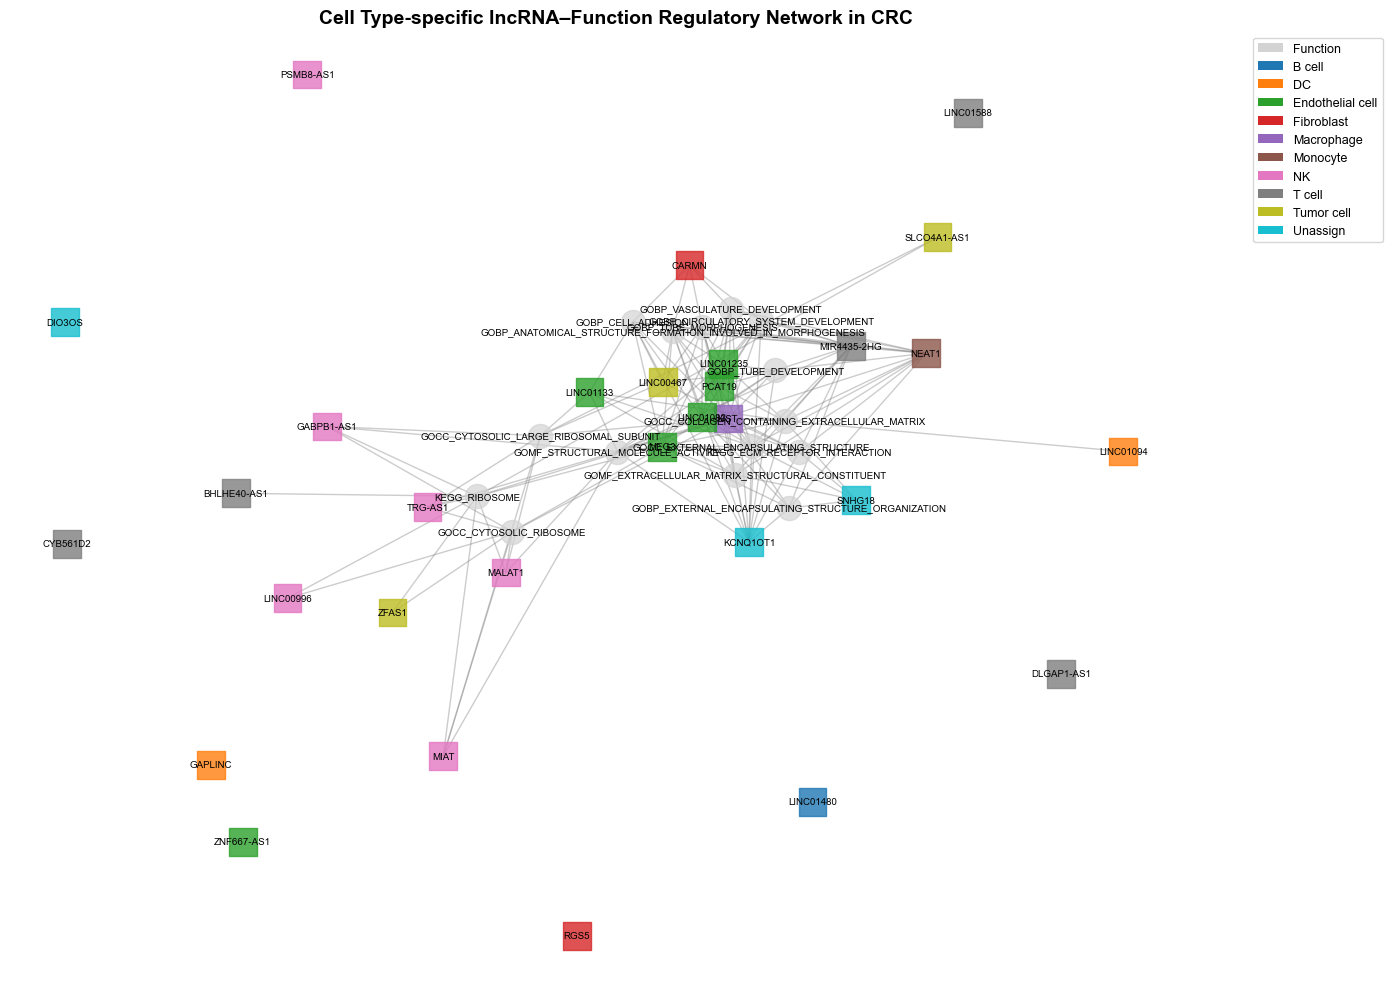

In [26]:
from curl_cffi import requests
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

plt.rcParams['font.family'] = 'Arial'

Tumor = 'CRC'
API = f"https://bio-bigdata.hrbmu.edu.cn/scolnc/searchAddSp?cancer={Tumor}"
response = requests.get(API, impersonate="chrome")
df = pd.DataFrame(response.json()['data'])

df['pval'] = pd.to_numeric(df['pval'], errors='coerce')
df = df.dropna(subset=['pval'])
df['function_list'] = df['function'].str.split(';')
df_expanded = df.explode('function_list').dropna(subset=['function_list'])
df_expanded = df_expanded[df_expanded['function_list'] != '']

G = nx.Graph()
for _, row in df_expanded.iterrows():
    lnc, func, cell = row['lncRNA'], row['function_list'], row['cellType']
    weight = -np.log10(row['pval']) if row['pval'] > 0 else 10
    G.add_node(lnc, type='lncRNA', cell=cell)
    G.add_node(func, type='function')
    G.add_edge(lnc, func, weight=weight)

# Filter
top_lnc = df.groupby('lncRNA')['avgLog2FC'].max().sort_values(ascending=False).head(30).index
top_funcs = df_expanded.groupby('function_list').size().sort_values(ascending=False).head(15).index
G = G.subgraph(set(top_lnc) | set(top_funcs))

lnc_nodes = [n for n, d in G.nodes(data=True) if d.get('type') == 'lncRNA']
func_nodes = [n for n, d in G.nodes(data=True) if d.get('type') == 'function']

# Auto colors by cell type
cells = sorted(set([G.nodes[n].get('cell') for n in lnc_nodes]))
colors = cm.tab10(np.linspace(0, 1, len(cells)))
cell_colors = {c: colors[i] for i, c in enumerate(cells)}
lnc_colors = [cell_colors.get(G.nodes[n].get('cell'), '#95A5A6') for n in lnc_nodes]

plt.figure(figsize=(14, 10))
pos = nx.spring_layout(G, k=2, seed=42)

nx.draw_networkx_nodes(G, pos, nodelist=lnc_nodes, node_shape='s', 
                       node_color=lnc_colors, node_size=400, alpha=0.8)
nx.draw_networkx_nodes(G, pos, nodelist=func_nodes, node_shape='o',
                       node_color='lightgray', node_size=300, alpha=0.7)
nx.draw_networkx_edges(G, pos, alpha=0.4, edge_color='gray')

nx.draw_networkx_labels(G, pos, font_size=7, font_family='Arial')

from matplotlib.patches import Patch
legend = [Patch(facecolor='lightgray', label='Function')] + \
         [Patch(facecolor=cell_colors[c], label=c) for c in cells]
plt.legend(handles=legend, loc='upper left', fontsize=9, bbox_to_anchor=(1.02, 1))
plt.title(f'Cell Type-specific lncRNA–Function Regulatory Network in {Tumor}', fontsize=14, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

## Example2

### MEG3 Co-regulation Network

In [3]:
# Co-regulated lncRNA Table
import pandas as pd
from curl_cffi import requests

Gene = "MEG3"
API_co = f"https://bio-bigdata.hrbmu.edu.cn/scolnc/searchAddCo?name={Gene}"
resp_co = requests.get(API_co, impersonate="chrome")
df_co = pd.DataFrame(resp_co.json()['data'])

print("\nCo-regulated lncRNA:")
df_co[['geneId1', 'lncRna1', 'geneId2', 'lncRna2', 'jaccordIndex',
       'intensityScore', 'cellType', 'tumorType', 'functionalType',
       'functional']].head(10)


Co-regulated lncRNA:


,geneId1,lncRna1,geneId2,lncRna2,jaccordIndex,intensityScore,cellType,tumorType,functionalType,functional
0,ENSG00000214548,MEG3,ENSG00000215386,MIR99AHG,0.657142857142857,1.80997574440164,Endothelial cell,CRC,GO,GOCC_COLLAGEN_CONTAINING_EXTRACELLULAR_MATRIX;...
1,ENSG00000214548,MEG3,ENSG00000143248,RGS5,0.56,1.56511663513854,Fibroblast,HCC,GO,GOMF_STRUCTURAL_MOLECULE_ACTIVITY;GOCC_CYTOSOL...
2,ENSG00000214548,MEG3,ENSG00000225383,SFTA1P,0.736842105263158,1.5804096773475,Fibroblast,HCC,GO,GOMF_STRUCTURAL_MOLECULE_ACTIVITY;GOCC_CYTOSOL...
3,ENSG00000214548,MEG3,ENSG00000226674,TEX41,1,-1.95165772607272,Unassign,BC,KEGG,KEGG_ECM_RECEPTOR_INTERACTION
4,ENSG00000214548,MEG3,ENSG00000270069,MIR222HG,1,1.96706535654971,Unassign,BC,KEGG,KEGG_ECM_RECEPTOR_INTERACTION
5,ENSG00000214548,MEG3,ENSG00000203706,SERTAD4-AS1,1,1.55931744010665,Fibroblast,CRC,KEGG,KEGG_ECM_RECEPTOR_INTERACTION;KEGG_FOCAL_ADHESION
6,ENSG00000214548,MEG3,ENSG00000172965,MIR4435-2HG,1,1.68883736543797,Fibroblast,CRC,KEGG,KEGG_ECM_RECEPTOR_INTERACTION;KEGG_FOCAL_ADHESION
7,ENSG00000214548,MEG3,ENSG00000250786,SNHG18,0.666666666666667,1.65169318225105,Fibroblast,CRC,KEGG,KEGG_ECM_RECEPTOR_INTERACTION;KEGG_FOCAL_ADHESION
8,ENSG00000214548,MEG3,ENSG00000245532,NEAT1,1,1.62511305633927,Fibroblast,CRC,KEGG,KEGG_ECM_RECEPTOR_INTERACTION;KEGG_FOCAL_ADHESION
9,ENSG00000214548,MEG3,ENSG00000237187,NR2F1-AS1,0.666666666666667,-1.94692317478737,Fibroblast,OV,KEGG,KEGG_ECM_RECEPTOR_INTERACTION;KEGG_FOCAL_ADHESION


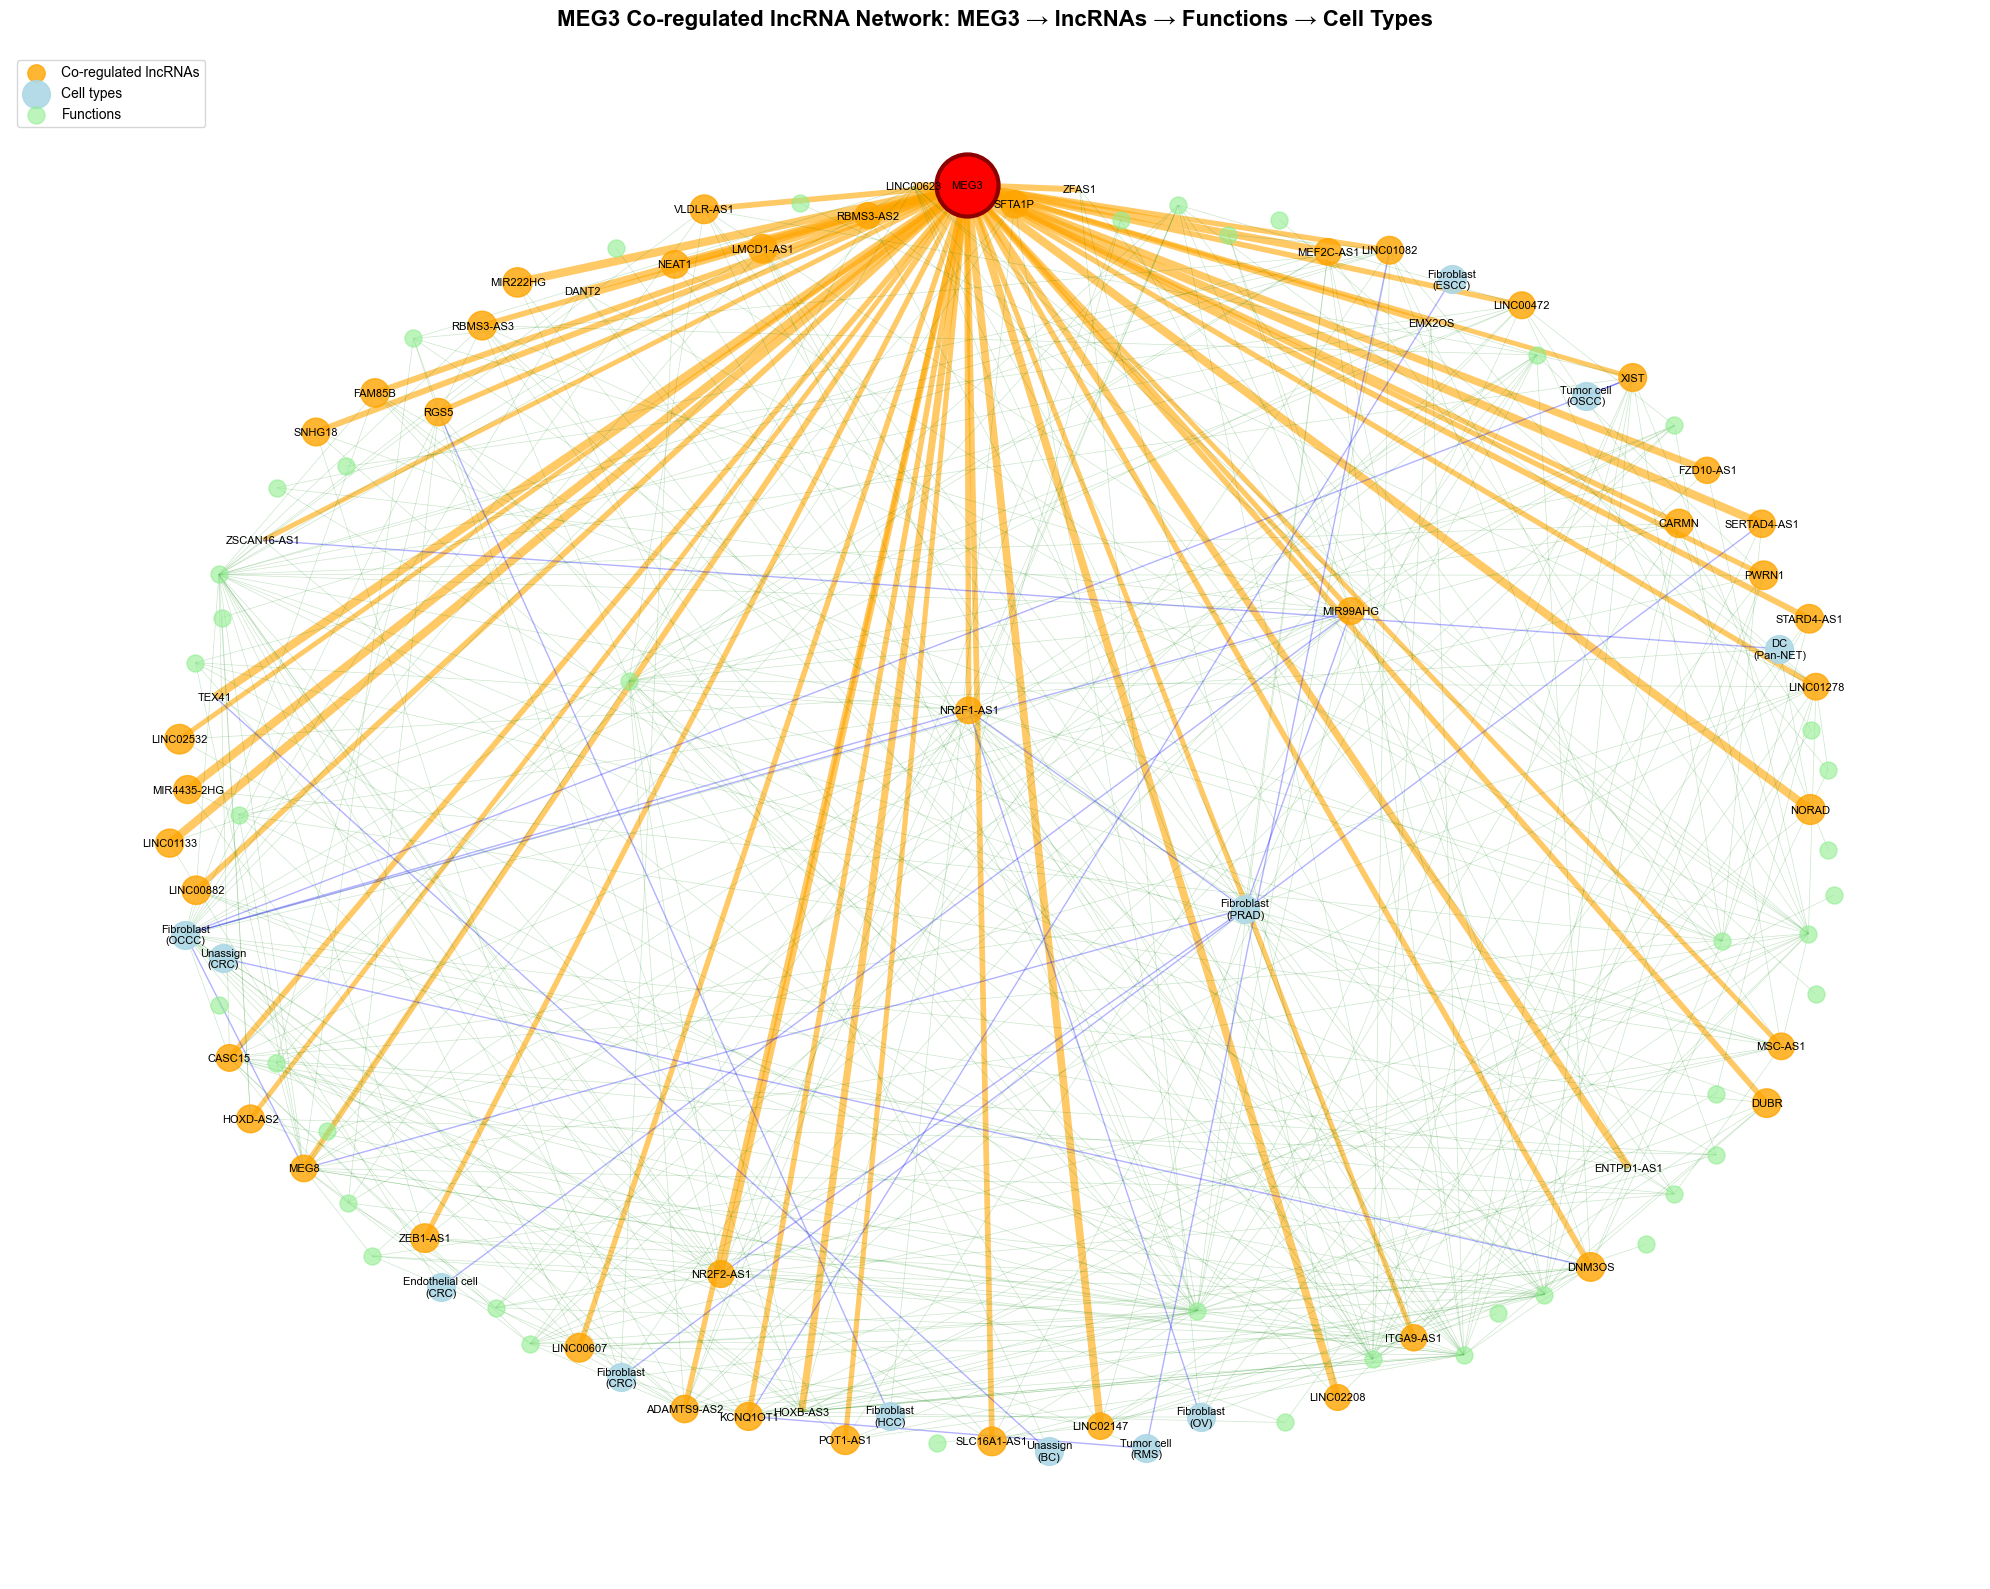

Network Statistics:
  Total nodes: 105
  MEG3 center: 1
  Co-regulated lncRNAs: 51
  Cell types: 12
  Functions: 41
Total edges: 440


In [ ]:
from curl_cffi import requests
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# Set Arial font
plt.rcParams['font.family'] = 'Arial'

# Configuration
Gene = "MEG3"
API_co = f"https://bio-bigdata.hrbmu.edu.cn/scolnc/searchAddCo?name={Gene}"

# Fetch data
response = requests.get(API_co, impersonate="chrome")
data = response.json()
df = pd.DataFrame(data['data'])

# Build network: MEG3 -> co-regulated lncRNAs -> functions -> cell types
G = nx.Graph()

# Add MEG3 as central node
G.add_node('MEG3', type='center', size=800)

for _, row in df.iterrows():
    lnc = row['lncRna2']
    cell = row['cellType']
    tumor = row['tumorType']
    functions = row['functional'].split(';') if pd.notna(row['functional']) else []
    jaccard = float(row['jaccordIndex'])
    intensity = float(row['intensityScore'])
    
    # Add lncRNA node
    G.add_node(lnc, type='lncRNA', size=300, intensity=intensity, tumor=tumor, cell=cell)
    G.add_edge('MEG3', lnc, weight=jaccard, intensity=intensity)
    
    # Add cell type node
    cell_label = f"{cell}\n({tumor})"
    G.add_node(cell_label, type='cell', size=400)
    G.add_edge(lnc, cell_label, weight=intensity)
    
    # Add function nodes (limit to top 5 for readability)
    for func in functions[:5]:
        # Extract GO term name
        func_short = func.split('_')[-1] if '_' in func else func
        func_short = func_short.replace('_', ' ')
        if len(func_short) > 25:
            func_short = func_short[:22] + '...'
        
        G.add_node(func_short, type='function', size=150)
        G.add_edge(lnc, func_short, weight=1)

# Separate nodes by type for plotting
center_nodes = [n for n, d in G.nodes(data=True) if d.get('type') == 'center']
lnc_nodes = [n for n, d in G.nodes(data=True) if d.get('type') == 'lncRNA']
cell_nodes = [n for n, d in G.nodes(data=True) if d.get('type') == 'cell']
func_nodes = [n for n, d in G.nodes(data=True) if d.get('type') == 'function']

# Plot
plt.figure(figsize=(20, 16))
pos = nx.spring_layout(G, k=5, seed=42, iterations=100)

# Draw edges with different colors based on connection type
# Edges: MEG3-lncRNA (weighted by Jaccard)
for edge in G.edges(data=True):
    if edge[0] == 'MEG3' or edge[1] == 'MEG3':
        width = 1 + 5 * edge[2]['weight']
        nx.draw_networkx_edges(G, pos, edgelist=[(edge[0], edge[1])], 
                               width=width, alpha=0.6, edge_color='orange')
    elif G.nodes[edge[0]].get('type') == 'lncRNA' and G.nodes[edge[1]].get('type') == 'cell':
        nx.draw_networkx_edges(G, pos, edgelist=[(edge[0], edge[1])], 
                               width=1, alpha=0.3, edge_color='blue')
    else:
        nx.draw_networkx_edges(G, pos, edgelist=[(edge[0], edge[1])], 
                               width=0.5, alpha=0.2, edge_color='green')

# Draw nodes
# MEG3 center
nx.draw_networkx_nodes(G, pos, nodelist=center_nodes, node_color='red', 
                       node_size=2000, alpha=1.0, edgecolors='darkred', linewidths=3)

# lncRNA nodes
lnc_sizes = [G.nodes[n].get('size', 300) * (0.5 + 0.5 * G.nodes[n].get('intensity', 0.5)) 
             for n in lnc_nodes]
nx.draw_networkx_nodes(G, pos, nodelist=lnc_nodes, node_color='orange', 
                       node_size=lnc_sizes, alpha=0.8, label='Co-regulated lncRNAs')

# Cell type nodes
nx.draw_networkx_nodes(G, pos, nodelist=cell_nodes, node_color='lightblue', 
                       node_size=400, alpha=0.9, label='Cell types')

# Function nodes
nx.draw_networkx_nodes(G, pos, nodelist=func_nodes, node_color='lightgreen', 
                       node_size=150, alpha=0.6, label='Functions')

# Draw labels (only for center, lncRNA, and cell types for clarity)
labels = {n: n for n in center_nodes}
labels.update({n: n for n in lnc_nodes})
labels.update({n: n for n in cell_nodes})
nx.draw_networkx_labels(G, pos, labels=labels, font_size=8, font_family='Arial')

plt.title('MEG3 Co-regulated lncRNA Network: MEG3 → lncRNAs → Functions → Cell Types', 
          fontsize=16, fontweight='bold', pad=20)
plt.legend(loc='upper left', fontsize=10)
plt.axis('off')
plt.tight_layout()
plt.show()

# Print statistics
print(f"Network Statistics:")
print(f"  Total nodes: {G.number_of_nodes()}")
print(f"  MEG3 center: 1")
print(f"  Co-regulated lncRNAs: {len(lnc_nodes)}")
print(f"  Cell types: {len(cell_nodes)}")
print(f"  Functions: {len(func_nodes)}")
print(f"Total edges: {G.number_of_edges()}")

### MEG3 Cell Type Specificity Network

In [2]:
# Cell type-specific lncRNA table
Gene = "MEG3"
API_sp = f"https://bio-bigdata.hrbmu.edu.cn/scolnc/searchAddSp?name={Gene}"
resp_sp = requests.get(API_sp, impersonate="chrome")
df_sp = pd.DataFrame(resp_sp.json()['data'])

print("\nCell type-specific lncRNA:")
df_sp[['geneId', 'lncRNA', 'tumorType', 'cellType', 'avgLog2FC', 'pct1',
       'pct2', 'function', 'funcState', 'funcIndex', 'lncColncState',
       'lncColncIndex', 'lncfunc', 'pval', 'pvalAdj']].head(10)


Cell type-specific lncRNA:


,geneId,lncRNA,tumorType,cellType,avgLog2FC,pct1,pct2,function,funcState,funcIndex,lncColncState,lncColncIndex,lncfunc,pval,pvalAdj
0,ENSG00000214548,MEG3,ATC,Fibroblast,2.25862927542694,0.920454545454545,0.0232724668814894,GOBP_AMIDE_BIOSYNTHETIC_PROCESS;GOBP_CELLULAR_...,1,https://sco-lnc.pages.dev/function/MEG3_functi...,1,https://sco-lnc.pages.dev/colnc/MEG3_colnc.html,1,0,0
1,ENSG00000214548,MEG3,BC,Epithelial cell,2.02394701369855,0.465346534653465,0.0174581005586592,NA,1,https://sco-lnc.pages.dev/function/MEG3_functi...,1,https://sco-lnc.pages.dev/colnc/MEG3_colnc.html,0,1.95374452603751e-241,3.67382120676093e-237
2,ENSG00000214548,MEG3,BC,Unassign,1.46656843527512,0.692307692307692,0.07986838169309,GOCC_ENDOPLASMIC_RETICULUM_LUMEN;GOCC_EXTERNAL...,1,https://sco-lnc.pages.dev/function/MEG3_functi...,1,https://sco-lnc.pages.dev/colnc/MEG3_colnc.html,1,3.17468363257623e-28,5.96967510269634e-24
3,ENSG00000214548,MEG3,CRC,Fibroblast,0.612376800120907,0.389705882352941,0.11460895228726,GOCC_COLLAGEN_CONTAINING_EXTRACELLULAR_MATRIX;...,1,https://sco-lnc.pages.dev/function/MEG3_functi...,1,https://sco-lnc.pages.dev/colnc/MEG3_colnc.html,1,8.97823288884335e-91,1.8598409429239e-86
4,ENSG00000214548,MEG3,CRC,Unassign,2.1224737563023,0.884792626728111,0.123171095849507,GOMF_TRANSCRIPTION_REGULATOR_ACTIVITY;GOMF_SEQ...,1,https://sco-lnc.pages.dev/function/MEG3_functi...,1,https://sco-lnc.pages.dev/colnc/MEG3_colnc.html,1,2.86381626450672e-229,5.93239539192567e-225
5,ENSG00000214548,MEG3,CRC,Endothelial cell,1.22216491903194,0.490481522956327,0.0961474593158419,GOCC_COLLAGEN_CONTAINING_EXTRACELLULAR_MATRIX;...,1,https://sco-lnc.pages.dev/function/MEG3_functi...,1,https://sco-lnc.pages.dev/colnc/MEG3_colnc.html,1,1.01274567240523e-215,2.09790266038744e-211
6,ENSG00000214548,MEG3,ESCC,Fibroblast,2.09252890672423,0.697448359659781,0.0257414661443761,GOMF_EXTRACELLULAR_MATRIX_STRUCTURAL_CONSTITUE...,1,https://sco-lnc.pages.dev/function/MEG3_functi...,1,https://sco-lnc.pages.dev/colnc/MEG3_colnc.html,1,0,0
7,ENSG00000214548,MEG3,GBM,Tumor cell,2.23844717160046,0.673330404217926,0.0553359683794466,GOBP_TISSUE_DEVELOPMENT;GOBP_ENZYME_LINKED_REC...,1,https://sco-lnc.pages.dev/function/MEG3_functi...,1,https://sco-lnc.pages.dev/colnc/MEG3_colnc.html,1,9.37927124327164e-69,1.596820929167e-64
8,ENSG00000214548,MEG3,HCC,Endothelial cell,0.391265909449432,0.110062893081761,0.015470408346825,NA,1,https://sco-lnc.pages.dev/function/MEG3_functi...,1,https://sco-lnc.pages.dev/colnc/MEG3_colnc.html,0,7.62402722336361e-60,1.37827164143967e-55
9,ENSG00000214548,MEG3,HCC,Fibroblast,1.59270075436793,0.434782608695652,0.00806380927338067,GOMF_STRUCTURAL_MOLECULE_ACTIVITY;GOCC_CYTOSOL...,1,https://sco-lnc.pages.dev/function/MEG3_functi...,1,https://sco-lnc.pages.dev/colnc/MEG3_colnc.html,1,0,0


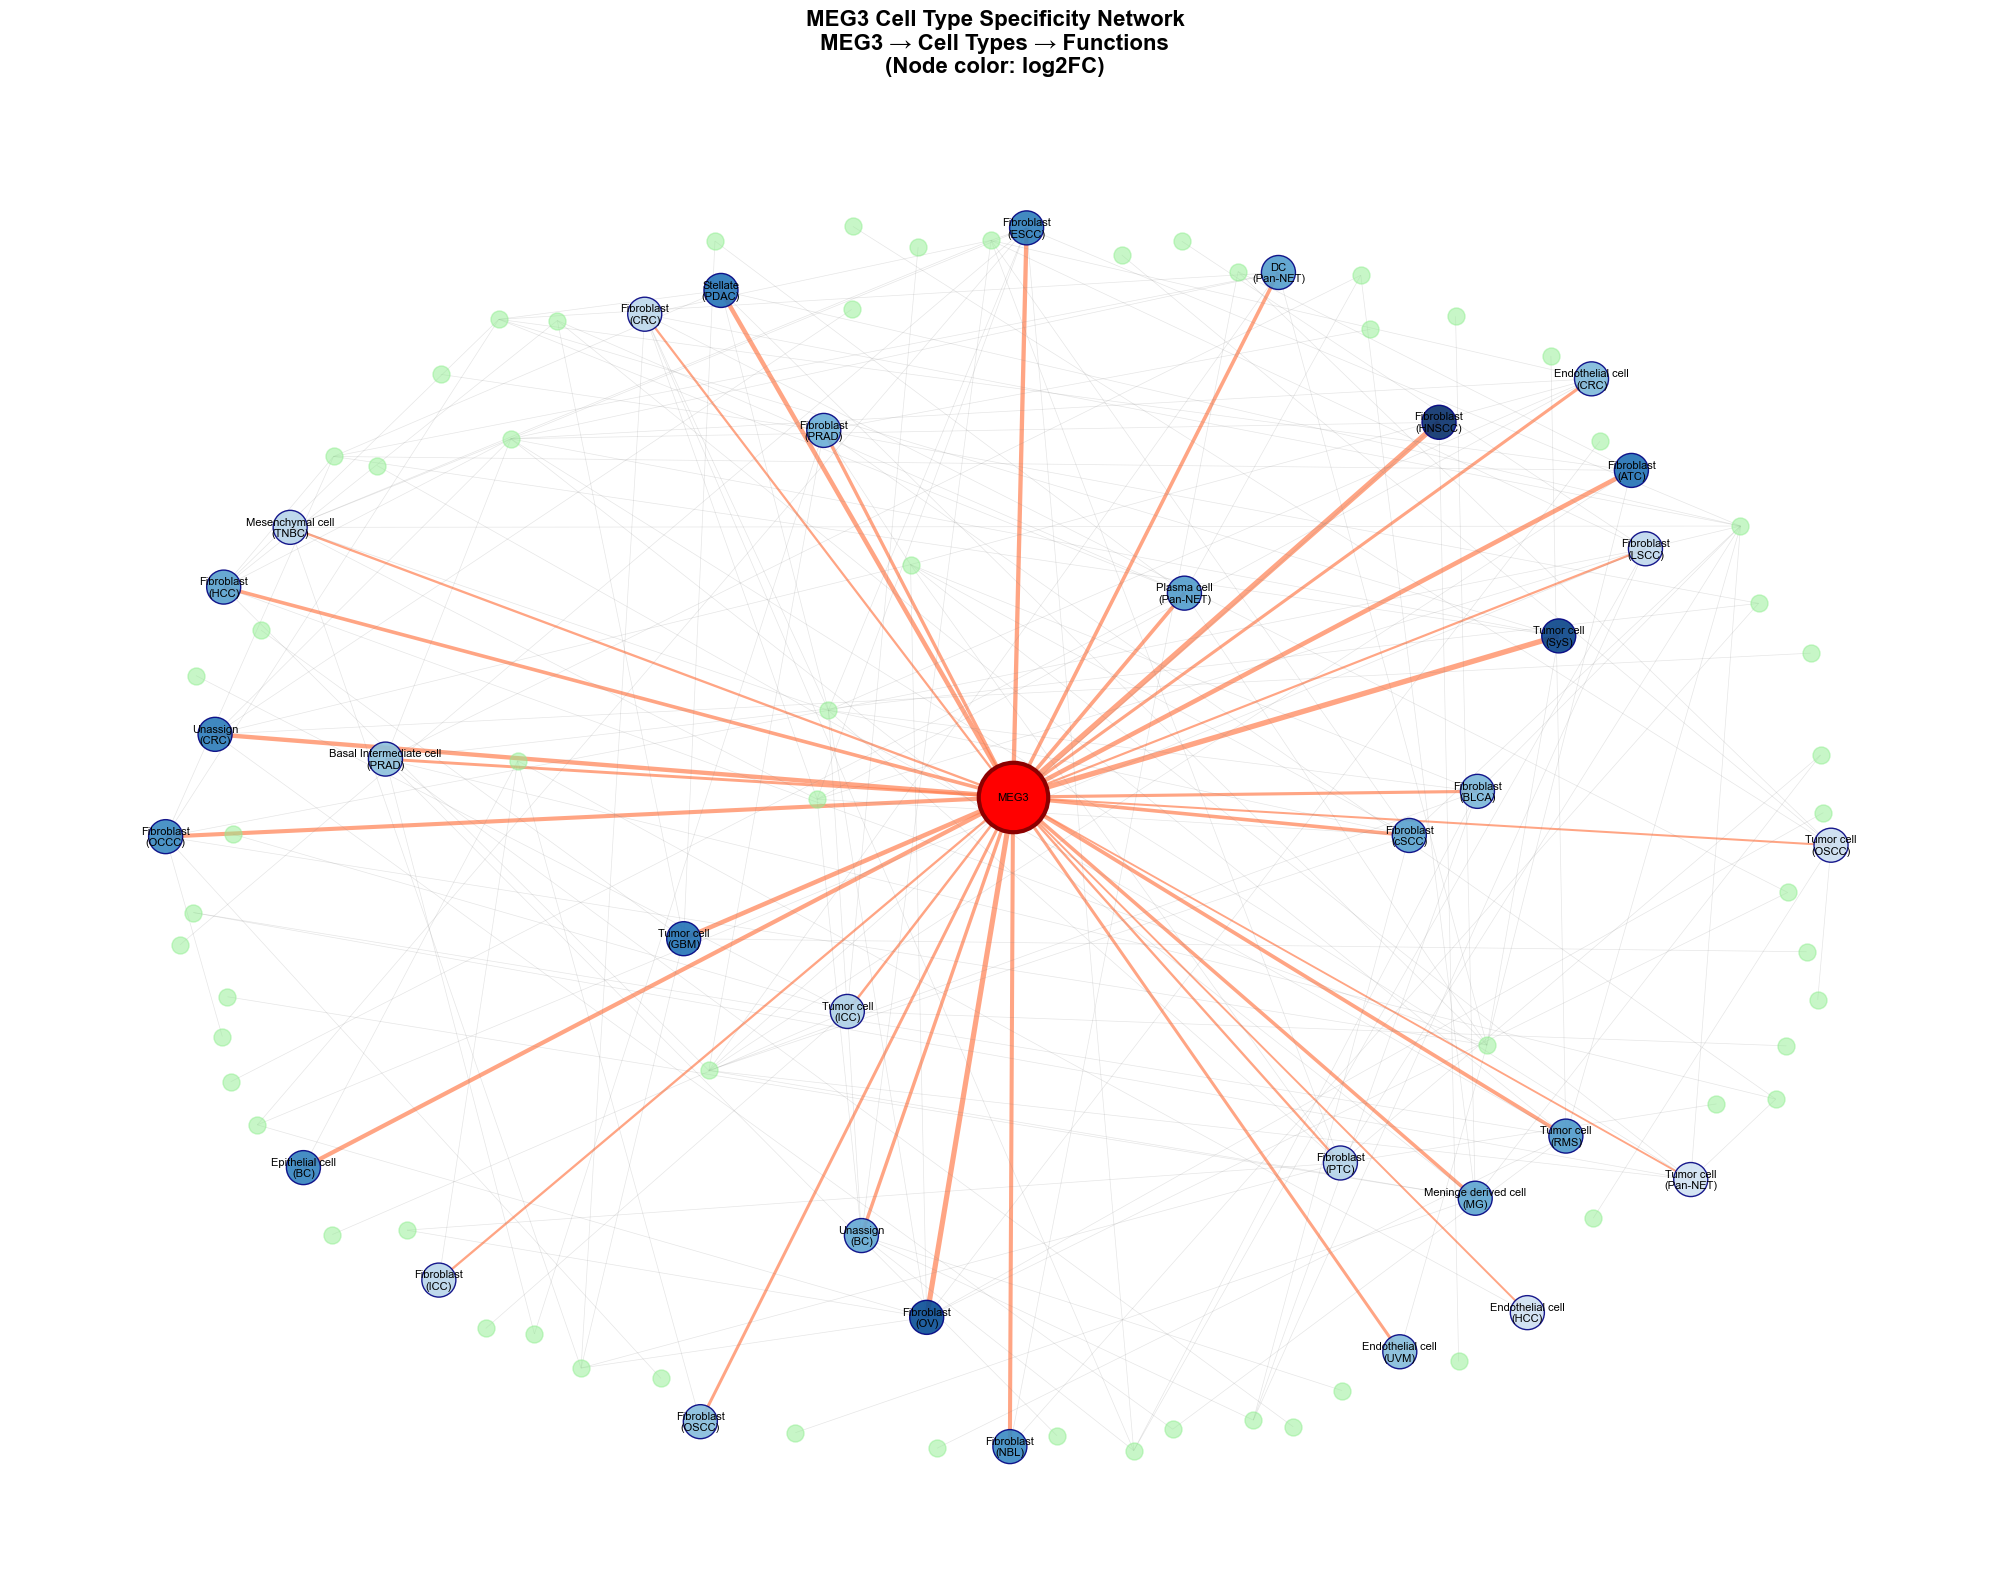

Network Statistics:
  Total nodes: 95
  MEG3 center: 1
  Cell types: 33
  Functions: 61
Total edges: 204

Cell types with log2FC:
  Fibroblast
(HNSCC): log2FC=3.127, p=0.00e+00
  Tumor cell
(SyS): log2FC=2.866, p=0.00e+00
  Fibroblast
(OV): log2FC=2.732, p=0.00e+00
  Fibroblast
(ATC): log2FC=2.259, p=0.00e+00
  Tumor cell
(GBM): log2FC=2.238, p=9.38e-69
  Stellate
(PDAC): log2FC=2.201, p=0.00e+00
  Unassign
(CRC): log2FC=2.122, p=2.86e-229
  Fibroblast
(ESCC): log2FC=2.093, p=0.00e+00
  Epithelial cell
(BC): log2FC=2.024, p=1.95e-241
  Fibroblast
(OCCC): log2FC=1.943, p=0.00e+00
  Fibroblast
(NBL): log2FC=1.912, p=1.26e-56
  Tumor cell
(RMS): log2FC=1.700, p=6.17e-171
  Plasma cell
(Pan-NET): log2FC=1.651, p=1.21e-129
  DC
(Pan-NET): log2FC=1.616, p=0.00e+00
  Fibroblast
(HCC): log2FC=1.593, p=0.00e+00
  Fibroblast
(cSCC): log2FC=1.575, p=0.00e+00
  Meninge derived cell
(MG): log2FC=1.540, p=0.00e+00
  Unassign
(BC): log2FC=1.467, p=3.17e-28
  Fibroblast
(PRAD): log2FC=1.389, p=2.69e-1

In [ ]:
from curl_cffi import requests
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# Set Arial font
plt.rcParams['font.family'] = 'Arial'

# Get data
Gene = "MEG3"
API_sp = f"https://bio-bigdata.hrbmu.edu.cn/scolnc/searchAddSp?name={Gene}"
resp_sp = requests.get(API_sp, impersonate="chrome")
df_sp = pd.DataFrame(resp_sp.json()['data'])

# Build network: MEG3 -> Cell types -> Functions
G = nx.Graph()

# Add MEG3 as central node
G.add_node('MEG3', type='center', size=1000)

for _, row in df_sp.iterrows():
    tumor = row['tumorType']
    cell = row['cellType']
    log2fc = float(row['avgLog2FC'])
    pval = float(row['pval'])
    functions = row['function'].split(';') if pd.notna(row['function']) else []
    
    # Create cell type label
    cell_label = f"{cell}\n({tumor})"
    
    # Add cell type node
    G.add_node(cell_label, type='cell', size=500, log2fc=log2fc, pval=pval)
    G.add_edge('MEG3', cell_label, weight=abs(log2fc), pval=pval)
    
    # Add function nodes (limit to top 8 for readability)
    func_list = []
    for func in functions[:8]:
        # Extract short name
        if func.startswith('GO'):
            func_short = func.split('_')[-1] if '_' in func else func
        elif func.startswith('KEGG'):
            func_short = func.split('_')[-1] if '_' in func else func
        else:
            func_short = func
        
        func_short = func_short.replace('_', ' ')
        if len(func_short) > 20:
            func_short = func_short[:18] + '..'
        
        if func_short not in func_list:
            func_list.append(func_short)
            G.add_node(func_short, type='function', size=150)
            G.add_edge(cell_label, func_short, weight=1)

# Separate nodes by type
center_nodes = [n for n, d in G.nodes(data=True) if d.get('type') == 'center']
cell_nodes = [n for n, d in G.nodes(data=True) if d.get('type') == 'cell']
func_nodes = [n for n, d in G.nodes(data=True) if d.get('type') == 'function']

# Plot
fig, ax = plt.subplots(figsize=(20, 16))
pos = nx.spring_layout(G, k=3, seed=42, iterations=100)

# Draw edges with different colors
# MEG3 -> Cell types (weighted by log2FC)
for edge in G.edges(data=True):
    if edge[0] == 'MEG3' or edge[1] == 'MEG3':
        width = 1 + 3 * min(edge[2]['weight'], 3) / 3
        nx.draw_networkx_edges(G, pos, edgelist=[(edge[0], edge[1])], 
                               width=width, alpha=0.7, edge_color='coral')
    else:
        nx.draw_networkx_edges(G, pos, edgelist=[(edge[0], edge[1])], 
                               width=0.5, alpha=0.2, edge_color='gray')

# Draw nodes
# MEG3 center
nx.draw_networkx_nodes(G, pos, nodelist=center_nodes, node_color='red', 
                       node_size=2500, alpha=1.0, edgecolors='darkred', linewidths=3)

# Cell type nodes (color by log2FC)
cell_log2fc = [G.nodes[n].get('log2fc', 0) for n in cell_nodes]
norm_log2fc = [(x - min(cell_log2fc)) / (max(cell_log2fc) - min(cell_log2fc) + 0.001) 
               for x in cell_log2fc]
cell_colors = plt.cm.Blues(np.array(norm_log2fc) * 0.8 + 0.2)
nx.draw_networkx_nodes(G, pos, nodelist=cell_nodes, node_color=cell_colors, 
                       node_size=600, alpha=0.9, edgecolors='navy', linewidths=1)

# Function nodes
nx.draw_networkx_nodes(G, pos, nodelist=func_nodes, node_color='lightgreen', 
                       node_size=150, alpha=0.5)

# Draw labels
labels = {n: n for n in center_nodes}
labels.update({n: n for n in cell_nodes})
nx.draw_networkx_labels(G, pos, labels=labels, font_size=8, font_family='Arial')

plt.title('MEG3 Cell Type Specificity Network\nMEG3 → Cell Types → Functions\n(Node color: log2FC)', 
          fontsize=16, fontweight='bold', pad=20)
plt.axis('off')
plt.tight_layout()
plt.show()

# Print statistics
print(f"Network Statistics:")
print(f"  Total nodes: {G.number_of_nodes()}")
print(f"  MEG3 center: 1")
print(f"  Cell types: {len(cell_nodes)}")
print(f"  Functions: {len(func_nodes)}")
print(f"Total edges: {G.number_of_edges()}")
print(f"\nCell types with log2FC:")
for cell in sorted(cell_nodes, key=lambda x: G.nodes[x].get('log2fc', 0), reverse=True):
    log2fc = G.nodes[cell].get('log2fc', 0)
    pval = G.nodes[cell].get('pval', 1)
    print(f"  {cell}: log2FC={log2fc:.3f}, p={pval:.2e}")